In [ ]:
import torch  # (⸝⸝⸝>﹏<⸝⸝⸝)
import torch.nn as nn
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers, normalizers
from transformers import PreTrainedTokenizerFast
from datasets import load_dataset
import itertools
import multiprocessing as mp
from tqdm import tqdm
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt
from IPython.display import clear_output

In [ ]:
# TODO faire apprendre les nl au modele


#  Preprocess (Tokenization)

In [ ]:

# config
TOKEN_NUMBER = 32000
LAYER_NUMBER = 8
PATH = "/home/gaspard/projets/epub"
LONGUEUR_BLOC = 2048  # Could do 4096 at the expense of training time


tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()
tokenizer.normalizer = normalizers.Sequence([normalizers.NFKC()])

trainer = trainers.BpeTrainer(
    vocab_size=TOKEN_NUMBER,
    special_tokens=["<|endoftext|>", "<|pad|>"],
    show_progress=True
)

full_dataset = load_dataset("text", data_dir=PATH, split="train")
dataset_sample = full_dataset.shuffle(seed=42).select(range(10000))

print("Entraînement du vocabulaire...")
tokenizer.train_from_iterator(dataset_sample["text"], trainer=trainer)

# Rust to object Transformers
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    eos_token="<|endoftext|>",
    pad_token="<|pad|>"
)


def tokenize_function(exemples):
    resultat = hf_tokenizer(exemples["text"], truncation=False, padding=False)
    
    # end of text (book) token addition
    for ids in resultat["input_ids"]:
        ids.append(hf_tokenizer.eos_token_id)
        
    return resultat

print("Étape 1/2 : Tokenisation massive...")
tokenized_dataset = full_dataset.map(
    tokenize_function,
    batched=True,
    num_proc=16,
    remove_columns=["text"] 
)

#CHUNKING
def group_texts(exemples):
    # Fatenisation dynamique
    concatenated = {
        k: list(itertools.chain.from_iterable(exemples[k])) 
        for k in exemples.keys()
    }
    
    total_length = len(concatenated["input_ids"])
    
    total_length = (total_length // LONGUEUR_BLOC) * LONGUEUR_BLOC
    
    # 2048
    result = {
        k: [t[i : i + LONGUEUR_BLOC] for i in range(0, total_length, LONGUEUR_BLOC)]
        for k, t in concatenated.items()
    }
    return result

lm_dataset = tokenized_dataset.map(
    group_texts,
    batched=True,
    num_proc=16
)

print(f"Finished ! | Blocs Nb : {len(lm_dataset)}")

# Model (Transformers layers)

In [ ]:


#organes
# Based on the Transformer architecture from the paper "Attention is all you need" by Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model): #dimention_model
        super().__init__()

        self.num_heads = 8
        max_seq_len = 2048  # Updated to match LONGUEUR_BLOC old val : 2048*2

        #qkv init
        self.linear_q = nn.Linear(d_model, d_model, bias=False) #Wq
        self.linear_k = nn.Linear(d_model, d_model, bias=False) #Wk
        self.linear_v = nn.Linear(d_model, d_model, bias=False) #Wv

        #mathnul Q by Kt
        #scale by the root of the dimention

        #mask
        triangle_mask = torch.tril(torch.ones(max_seq_len, max_seq_len))
        self.register_buffer("masque", triangle_mask.view(1, 1, max_seq_len, max_seq_len))
        
        #softmax
        #mathnul with v

        #output
        self.linear_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self,x):

        q = self.linear_q (x)
        k = self.linear_k (x)
        v = self.linear_v (x)

        Batch, Temps, d_model = x.size()
        #  (Batch, Temps, 512) to (Batch, 8_têtes, Temps, 64_dim)
        q = q.view(Batch, Temps, 8, 64).transpose(1,2)
        k = k.view(Batch, Temps, 8, 64).transpose(1,2)
        v = v.view(Batch, Temps, 8, 64).transpose(1,2)

        #attention
        scores = (q @ k.transpose(-2,-1))/((d_model/self.num_heads) ** 0.5)

        # Clamp scores to prevent overflow in softmax
        scores = torch.clamp(scores, min=-1e4, max=1e4)

        #mask
        temp_mask = self.masque[..., :Temps, :Temps]
        scores = scores.masked_fill_(temp_mask == 0, float('-inf'))


        scores = nn.Softmax(dim=-1)(scores)

        attention = scores@v 
        
        #head merge
        output = attention.transpose(1, 2).contiguous().view(Batch, Temps, d_model)

        output = self.linear_out(output)


        return output



class FeedForward(nn.Module):
    def __init__(self, d_model):
            super().__init__()
            self.linear1 = nn.Linear(d_model, 4*d_model)
            self.relu = nn.ReLU() #TODO check for a Gelu
            self.linear2 = nn.Linear(d_model*4, d_model)
        
    def forward(self,x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x
    


#transformer
class TransformerBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        #call organes
        self.attention = MultiHeadAttention(d_model)
        self.feed_forward = FeedForward(d_model)

            #amortissement (to avoid gradient explosion)
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)


    def forward(self, x):
        #pre-norm architecture

        attention_out = self.attention(self.layernorm1(x))
        x = x + attention_out

        #nromalisation
        x = x +self.feed_forward(self.layernorm2(x))

        # (Batch, 4096, 512) -> (Batch, 4096, 32000)
        #logits = self.lm_head(x)
        return x
        

class MainModel(nn.Module):
    def __init__(self, vocab_size = TOKEN_NUMBER, d_model=512, num_couches=LAYER_NUMBER):
        super().__init__()

        self.pos_embedding = nn.Embedding(2048, d_model)  # Updated to match LONGUEUR_BLOC

        #embedding
        self.embedding = nn.Embedding(vocab_size, d_model) 

        #alignement
        self.couches = nn.ModuleList([
            TransformerBlock(d_model) for _ in range(num_couches)
        ])

        #normalisation
        self.final_norm = nn.LayerNorm(d_model)

        # --> tete d'écriture
        self.linear = nn.Linear(d_model, vocab_size, bias=False)


    def forward(self, idx):
        # idx : tensor (Batch, 4096) [tokens]
        Batch, Temps = idx.size()
        #pad_mask = (idx == 0) # Format : (Batch, Temps) mask de padding #CREAIT UNE LOSS NaN


        pos = torch.arange(0, Temps, dtype=torch.long, device=idx.device)
        x = self.embedding(idx) + self.pos_embedding(pos)

        for couche in self.couches:
            x = couche(x)

        #norm
        x = self.final_norm(x)

        logits = self.linear(x)

        return logits




    

## Batch feeder

In [5]:
import torch
from torch.utils.data import DataLoader, Subset

"""
def feeder_worker(dataset_indices, conn, batch_size=32):
    
    try:
        subset = Subset(lm_dataset, dataset_indices)
        dataloader = DataLoader(
            subset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=False,  # CPU only
            drop_last=True  # Évite batches incomplets
        )

        
        for batch in dataloader:
            conn.send(batch)  # Envoyer batch CPU

        conn.send(None)  # Fin

    except Exception as e:
        conn.send(f"ERROR: {str(e)}")
    finally:
        conn.close()

class MasterFeeder:
    #Master feeder multiprocess avec workers CPU.

    def __init__(self, lm_dataset, worker_count=4, batch_size=32, device='cuda'):
        self.lm_dataset = lm_dataset
        self.worker_count = worker_count
        self.batch_size = batch_size
        self.device = device
        self.workers = []
        self.conns = []

    def init_workers(self):
        total_len = len(self.lm_dataset)
        for i in range(self.worker_count):
            indices = list(range(i, total_len, self.worker_count))
            master_conn, worker_conn = mp.Pipe()
            p = mp.Process(
                target=feeder_worker,
                args=(indices, worker_conn, self.batch_size)
            )
            p.start()
            self.workers.append(p)
            self.conns.append(master_conn)

    def get_batches(self):
        active_conns = self.conns[:]
        while active_conns:
            for conn in active_conns[:]:
                try:
                    batch = conn.recv()
                    if batch is None:
                        active_conns.remove(conn)
                        conn.close()
                    elif isinstance(batch, str) and batch.startswith("ERROR"):
                        print(f"Worker error: {batch}")
                        active_conns.remove(conn)
                        conn.close()
                    else:
                        # Move to GPU ici (main process)
                        gpu_batch = {k: v.to(self.device) for k, v in batch.items()}
                        yield gpu_batch
                except EOFError:
                    active_conns.remove(conn)
                    conn.close()

    def stop_workers(self):
        for p in self.workers:
            if p.is_alive():
                p.terminate()
                p.join()
        for conn in self.conns:
            if not conn.closed:
                conn.close()
"""
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def pad_collate_fn(batch):
    """Bouche les trous avec des 0 pour que le batch soit parfaitement rectangulaire"""
    
    
    sequences = [torch.tensor(item['input_ids'], dtype=torch.long).squeeze() for item in batch]
    
    # pad_sequence rajoute des 0 pour que tout le monde ait la taille du plus grand
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    
    return {'input_ids': padded_seqs}


# On recrée officiellement le dataloader avec la fonction mise à jour
dataloader = DataLoader(
    lm_dataset,
    batch_size= 4, #temp reduction a modif later (old value : 32)
    shuffle=True,
    num_workers=4,       
    pin_memory=True,     
    drop_last=True,
    prefetch_factor=2,
    collate_fn=pad_collate_fn 
)


    

## Training loop

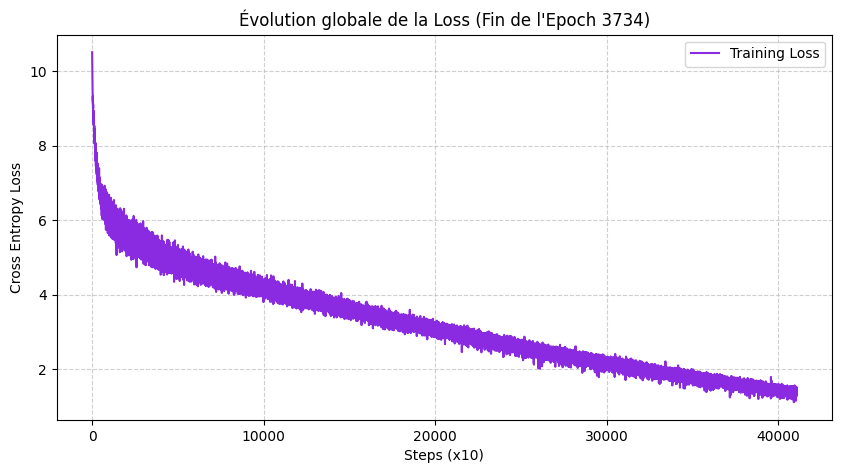

Epoch 3735:  42%|████▏     | 44/104 [00:04<00:06,  8.99it/s, Loss=1.3916]


KeyboardInterrupt: 

In [7]:

ITERATIONS = 100000000

if __name__ == '__main__':
    
    model = MainModel()
    model.to('cuda')
    
    # ---> CHANGEMENT 1 : L'Optimizer pour Transformer (AdamW + betas)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6, betas=(0.9, 0.98), weight_decay=0.01)

    #Gradient Accumulation + Mixed Precision application
    scaler = GradScaler('cuda')
    accumulation_steps = 4  # Accumule 4 mini-batches avant update
    
    
    historique_loss = []

    for epoch in range(ITERATIONS):
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
        

        # LA BOUCLE SUR LES DONNÉES
        for step, batch in pbar:
            with autocast(device_type='cuda'):
                # On récupère les tokens et on les met sur le GPU
                input_ids = batch['input_ids'].to('cuda', non_blocking=True) #probable memory leak
                
                #optimizer.zero_grad()
                
                logits = model(input_ids)

                # Check for inf/nan in logits
                if torch.isinf(logits).any() or torch.isnan(logits).any():
                    print(f"Inf/NaN in logits at step {step}, skipping")
                    continue



                # Next-token prediction : on décale d'un cran
                shift_logits = logits[..., :-1, :].contiguous()
                shift_labels = input_ids[..., 1:].contiguous()
                
                loss = torch.nn.functional.cross_entropy(   #check pr changer le calcul de la loss later
                    shift_logits.view(-1, shift_logits.size(-1)),
                    shift_labels.view(-1),
                )

                scaler.scale(loss).backward()

                

                if (step + 1) % accumulation_steps == 0:
                    # désécalise les gradients
                    scaler.unscale_(optimizer)

                    # Clip gradients to prevent explosion
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
                    torch.cuda.empty_cache() #check pr perte de vitesse
                
                # Petit affichage pour suivre que tout va bien
                '''if step % 1000 == 0:
                    print(f"Epoch {epoch} | Step {step} | Loss: {loss.item():.4f}")'''
                
                if step % 10 == 0:  # On stocke la loss toutes les 10 steps pour pas surcharger la RAM
                    current_loss = loss.item()
                    historique_loss.append(current_loss)
                
                    # Mise à jour silencieuse de la barre tqdm (au lieu du print)
                    pbar.set_postfix({'Loss': f"{current_loss:.4f}"})
        
        clear_output(wait=True) 
        
        plt.figure(figsize=(10, 5))
        plt.plot(historique_loss, label='Training Loss', color='#8A2BE2', linewidth=1.5) 
        plt.title(f"Évolution globale de la Loss (Fin de l'Epoch {epoch})")
        plt.xlabel("Steps (x10)")
        plt.ylabel("Cross Entropy Loss")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()

In [8]:
chemin_final = "Finished models/FreakyLLM.pth"
torch.save(model.state_dict(), chemin_final)

hf_tokenizer.save_pretrained("Finished models/mon_tokenizer_perso")

('Finished models/mon_tokenizer_perso/tokenizer_config.json',
 'Finished models/mon_tokenizer_perso/tokenizer.json')

In [9]:
model = MainModel()
model.load_state_dict(torch.load("Finished models/FreakyLLM.pth", map_location="cpu"))
model.eval()

MainModel(
  (pos_embedding): Embedding(2048, 512)
  (embedding): Embedding(32000, 512)
  (couches): ModuleList(
    (0-7): 8 x TransformerBlock(
      (attention): MultiHeadAttention(
        (linear_q): Linear(in_features=512, out_features=512, bias=False)
        (linear_k): Linear(in_features=512, out_features=512, bias=False)
        (linear_v): Linear(in_features=512, out_features=512, bias=False)
        (linear_out): Linear(in_features=512, out_features=512, bias=False)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (relu): ReLU()
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
      )
      (layernorm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
  )
  (final_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (linear): Linear(in_features=512, out_features=32000, bias=False)
)

## Inference cell

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MainModel()
model.load_state_dict(torch.load(
    "Finished models/FreakyLLM.pth",
    map_location=device
))
model.to(device)
model.eval()

#prompt = "Onced upon a time"
prompt = "I like it when"

enc = hf_tokenizer(prompt, return_tensors="pt")
input_ids = enc["input_ids"].to(device)

# Greedy EOS suppression (endoftext token)
eos_id = hf_tokenizer.eos_token_id
max_new_tokens = 800

with torch.no_grad():
    for _ in range(max_new_tokens):
        logits = model(input_ids)  # (B, T, V)

        # Make EOS impossible to select for the next token (greedy)
        logits[:, -1, eos_id] = -float("inf")

        # Greedy selection
        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)

        # If EOS somehow predicted, stop without appending it
        if next_token.item() == eos_id:
            break

        input_ids = torch.cat([input_ids, next_token], dim=1)

generated = hf_tokenizer.decode(input_ids[0], skip_special_tokens=True)
print(generated)

I like it when it is to make a regular assumption. We each morning. You do is that, you should be_ is working. I do with you can help you are and make a DVD. You can be. I do with that this? I need to make from the way. I could be. The way is a _isode will handle this room. I can never a while I do. I can be. I can make it. I will be true. I make the room. The other things and the next as a good and are all the next? I am not a way for someone a lot of the next, and I are in a while I have by you. I are. I will be cautious, you. I can say. I was a good one of the way for the most of the way, but there. The work in a few things up. I am so I am doing the room, I will a pause have. The way to be in that this. The only one example. The man in the shrine—are at all that can be badlyed there a. I am or the next morning. I. I do more and do. The man and a kind the end, I am doing a bookshelf and to the next on every day and that the end of a good deal, I am too. I can bring. The events. I do

: 